In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable

from torch.utils.data import Dataset,DataLoader

from tokenizers import ByteLevelBPETokenizer
from tokenizers.trainers import BpeTrainer
from tokenizers import Tokenizer, models, pre_tokenizers, decoders, trainers, processors
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace

from torchinfo import summary
import math


САМ МИПЛ

In [12]:
tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)


tokenizer.decoder = decoders.ByteLevel()
trainer = BpeTrainer(
    vocab_size=15000,
    special_tokens=["[PAD]", "[UNK]", "[SOS]", "[EOS]"],
    min_frequency=2
)

files = ["VocabText.txt"]
tokenizer.train(files, trainer)

sos_token_id = tokenizer.token_to_id("[SOS]")
eos_token_id = tokenizer.token_to_id("[EOS]")

MAX_LEN = 512
tokenizer.enable_padding(length=MAX_LEN)
tokenizer.enable_truncation(max_length=MAX_LEN)
tokenizer.save("mrplip_17M_3_tokenizer.json")



In [22]:
class SelfAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        self.qkv = nn.Linear(embed_size, embed_size * 3)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, T, 3, self.heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        mask = torch.tril(torch.ones(T, T)).to(x.device)
        scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = torch.softmax(scores, dim=-1)
        out = attn @ v
        out = out.transpose(1, 2).reshape(B, T, C)
        return self.fc_out(out)

In [23]:
class Block(nn.Module):
    def __init__(self, embed_size, heads, dropout=0.1):
        super().__init__()
        self.attn = SelfAttention(embed_size, heads)
        self.ln1 = nn.LayerNorm(embed_size)
        self.ff = nn.Sequential(
            nn.Linear(embed_size, 4 * embed_size),
            nn.GELU(),
            nn.Linear(4 * embed_size, embed_size),
            nn.Dropout(dropout),
        )
        self.ln2 = nn.LayerNorm(embed_size)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

In [24]:
class MipleModel(nn.Module):
    def __init__(self, vocab_size, embed_size, block_size, heads, decisions_count, emotions_count, market_features, sentiments_count, tactics_count, n_layers, dropout=0.1):
        super(MipleModel, self).__init__()
        self.block_size = block_size
        self.token_embed = nn.Embedding(vocab_size, embed_size)
        self.pos_embed = nn.Embedding(block_size, embed_size)

        self.blocks = nn.Sequential(*[Block(embed_size, heads, dropout) for _ in range(n_layers)])

        self.market_proj = nn.Linear(market_features, embed_size)
        self.sent_proj = nn.Linear(sentiments_count, embed_size)

        combined_input_size = (embed_size * 3) + emotions_count + sentiments_count

        self.buy_decision = nn.Sequential(
            nn.Linear(combined_input_size, embed_size),
            nn.ReLU(),
            nn.Linear(embed_size, embed_size),
            nn.Linear(embed_size, decisions_count),
        )

        self.emotions_choicer = nn.Linear(combined_input_size, emotions_count)
        self.tactic_choicer = nn.Linear(combined_input_size, tactics_count)

        # выбор акции: к каждой акции клеим личность и считаем балл
        self.stock_selector = nn.Sequential(
            nn.Linear(embed_size * 2, embed_size),
            nn.ReLU(),
            nn.Linear(embed_size, 1),
        )

        self.ln_f = nn.LayerNorm(embed_size)
        self.fc = nn.Linear(embed_size, vocab_size)

    def forward(self, market_seq, prompt_seq, news_seq, current_emotions, sentiments_config):
        B, T = prompt_seq.shape
        

        token_embeddings = self.token_embed(prompt_seq)
        position_embeddings = self.pos_embed(torch.arange(T, device=prompt_seq.device))
        x = token_embeddings + position_embeddings
        x = self.blocks(x)


        market_emb = self.market_proj(market_seq)
        news_emb = self.token_embed(news_seq) 

        market_emb_mean = torch.mean(market_emb, dim=1)
        news_emb_mean = torch.mean(news_emb, dim=1)
        
        x_mean = torch.mean(x, dim=1)

        sent_emb = self.sent_proj(sentiments_config)

        combined = torch.cat((x_mean, market_emb_mean, news_emb_mean, current_emotions, sentiments_config), dim=1)

        trade_logits = self.buy_decision(combined)
        new_emotions = self.emotions_choicer(combined)
        tactic_logits = self.tactic_choicer(combined)

        # балл каждой акции с учётом настроенной личности
        n_stocks = market_emb.shape[1]
        sent_rep = sent_emb.unsqueeze(1).expand(-1, n_stocks, -1)
        stock_feat = torch.cat((market_emb, sent_rep), dim=2)
        stock_logits = self.stock_selector(stock_feat).squeeze(-1)

        x_norm = self.ln_f(x)
        text_logits = self.fc(x_norm) 

        return trade_logits, new_emotions, tactic_logits, stock_logits, text_logits

In [ ]:
# тестовый прогон
vocab_size = tokenizer.get_vocab_size()
embed_size = 512
block_size = 512
heads = 8
decisions_count = 3
emotions_count = 3
market_features = 4
sentiments_count = 7
# число тактик = уникальные значения в датасете (должно совпадать с чекпоинтом)
import json as _json
with open("MipleDataset.json", encoding="utf-8") as _f:
    tactics_count = len({s["tactic"] for s in _json.load(_f)})
stocks_count = 8
n_layers = 4

model = MipleModel(vocab_size, embed_size, block_size, heads, decisions_count, emotions_count, market_features, sentiments_count, tactics_count, n_layers)

dummy_prompt = torch.randint(0, vocab_size, (2, 128), dtype=torch.long)
dummy_market = torch.randn(2, stocks_count, market_features)
dummy_news = torch.randint(0, vocab_size, (2, 20), dtype=torch.long)
dummy_emotions = torch.randn(2, emotions_count)
dummy_sentiments = torch.randn(2, sentiments_count)


trade_logits, new_emotions, tactic_logits, stock_logits, text_logits = model(dummy_market, dummy_prompt, dummy_news, dummy_emotions, dummy_sentiments)

print("trade logits shape:", trade_logits.shape)
print("new emotions shape:", new_emotions.shape)
print("tactic logits shape:", tactic_logits.shape)
print("stock logits shape:", stock_logits.shape)
print("text logits shape:", text_logits.shape)

model_stats = summary(
    model, 
    input_data=(dummy_market, dummy_prompt, dummy_news, dummy_emotions, dummy_sentiments),
    col_names=["input_size", "output_size", "num_params", "kernel_size"],
    depth=3
)

print(model_stats)

trade logits shape: torch.Size([2, 3])
new emotions shape: torch.Size([2, 3])
tactic logits shape: torch.Size([2, 21])
stock logits shape: torch.Size([2, 8])
text logits shape: torch.Size([2, 128, 3261])
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
MipleModel                               [2, 8, 4]                 [2, 3]                    --                        --
├─Embedding: 1-1                         [2, 128]                  [2, 128, 512]             1,669,632                 --
├─Embedding: 1-2                         [128]                     [128, 512]                262,144                   --
├─Sequential: 1-3                        [2, 128, 512]             [2, 128, 512]             --                        --
│    └─Block: 2-1                        [2, 128, 512]             [2, 128, 512]             --                        --
│    │    └─LayerNorm: 3-1               [2, 128, 512]

In [26]:
THEMES = ["технологии", "медицина", "финансы", "энергетика", "товары", "недвижимость",
          "сырьё", "промышленность", "связь", "спорт", "развлечения", "транспорт", "агро"]
DIR_MAP = {"рост": 1.0, "флэт": 0.0, "падение": -1.0}
SENTIMENTS = ["оптимист", "рискованный", "систематичный", "консерватист", "интроверт", "убежденный", "интуитивный"]


class FineTuningDataset(Dataset):
    def __init__(self, tokenizer, samples, max_len=512, max_stocks=8):
        super().__init__()
        self.tokenizer = tokenizer
        self.samples = samples
        self.max_len = max_len
        self.max_stocks = max_stocks
        # словарь тактик строим прямо из датасета
        tactics = sorted({s["tactic"] for s in samples})
        self.tactic2idx = {t: i for i, t in enumerate(tactics)}

    def __len__(self):
        return len(self.samples)

    def encode_market(self, stocks_states):
        names = list(stocks_states.keys())
        rows = []
        for name in names:
            sphere, price, dir_v, vol = stocks_states[name]
            sphere_idx = THEMES.index(sphere) / len(THEMES) if sphere in THEMES else 0.0
            rows.append([sphere_idx, float(price), DIR_MAP.get(dir_v, 0.0), float(vol)])
        while len(rows) < self.max_stocks:
            rows.append([0.0, 0.0, 0.0, 0.0])
        return torch.tensor(rows[:self.max_stocks], dtype=torch.float), names

    def __getitem__(self, index):
        s = self.samples[index]

        context = " ".join(s["messages"])
        text = f"{context} [SOS] {s['answer']} [EOS]"
        prompt_ids = torch.tensor(self.tokenizer.encode(text).ids, dtype=torch.long)

        news = " ".join(s["events"])
        news_ids = torch.tensor(self.tokenizer.encode(news).ids, dtype=torch.long)

        market, names = self.encode_market(s["stocks_states"])

        emotions = torch.tensor(s["emotions"], dtype=torch.float)
        sentiments = torch.tensor(s["basic_sentiments_parameters"], dtype=torch.float)
        decision = torch.tensor(s["decisions"].index(1), dtype=torch.long)
        stock_target = torch.tensor(names.index(s["target_stock"]) if s["target_stock"] in names else 0, dtype=torch.long)
        tactic_target = torch.tensor(self.tactic2idx[s["tactic"]], dtype=torch.long)

        return market, prompt_ids, news_ids, emotions, sentiments, decision, stock_target, tactic_target

In [27]:
import json

with open("MipleDataset.json", encoding="utf-8") as f:
    samples = json.load(f)

dataset = FineTuningDataset(tokenizer, samples, max_len=MAX_LEN, max_stocks=stocks_count)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

tactics_count = len(dataset.tactic2idx)
print("сэмплов:", len(dataset), "тактик:", tactics_count)


def make_persona(active, base=0.1, strong=0.9):
    # настройка сети под себя: включаем нужные сентименты
    vec = torch.full((len(SENTIMENTS),), base)
    for s in active:
        vec[SENTIMENTS.index(s)] = strong
    return vec.unsqueeze(0)


persona = make_persona(["интуитивный", "систематичный"])
print("персона:", dict(zip(SENTIMENTS, persona.squeeze().tolist())))

сэмплов: 1592 тактик: 19
персона: {'оптимист': 0.10000000149011612, 'рискованный': 0.10000000149011612, 'систематичный': 0.8999999761581421, 'консерватист': 0.10000000149011612, 'интроверт': 0.10000000149011612, 'убежденный': 0.10000000149011612, 'интуитивный': 0.8999999761581421}


In [19]:
class TextDataset(Dataset):
    def __init__(self, tokenizer, samples, use_messages=True):
        super().__init__()
        self.tokenizer = tokenizer
        # вытаскиваем сырой текст из основного датасета (реплики + контекст)
        seen = set()
        self.texts = []
        for s in samples:
            chunk = list(s["messages"]) if use_messages else []
            chunk.append(s["answer"])
            for t in chunk:
                t = t.strip()
                if t and t not in seen:
                    seen.add(t)
                    self.texts.append(t)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = f"[SOS] {self.texts[index]} [EOS]"
        return torch.tensor(self.tokenizer.encode(text).ids, dtype=torch.long)


text_dataset = TextDataset(tokenizer, samples)
text_loader = DataLoader(text_dataset, batch_size=8, shuffle=True)

# складываем сырой текст в отдельный файл
with open("RawText.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(text_dataset.texts))

print("текстов:", len(text_dataset))

текстов: 763


In [20]:
model = MipleModel(vocab_size, embed_size, block_size, heads, decisions_count, emotions_count, market_features, sentiments_count, tactics_count, n_layers)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

ce = nn.CrossEntropyLoss(ignore_index=tokenizer.token_to_id("[PAD]"))
mse = nn.MSELoss()

# веса классов решений — данные перекошены в hold, иначе голова схлопывается в один класс
dec_counts = [0, 0, 0]
for s in samples:
    dec_counts[s["decisions"].index(1)] += 1
dec_w = torch.tensor([len(samples) / (3 * c) if c else 0.0 for c in dec_counts])
ce_trade = nn.CrossEntropyLoss(weight=dec_w)

pretrain_losses = []
history = {"total": [], "text": [], "trade": [], "stock": [], "tactic": [], "emo": []}


pretrain_epochs = 2
model.train()
for epoch in range(pretrain_epochs):
    for prompt_ids in text_loader:
        B = prompt_ids.shape[0]
        z_market = torch.zeros(B, stocks_count, market_features)
        z_news = torch.full((B, 1), sos_token_id, dtype=torch.long)
        z_emo = torch.zeros(B, emotions_count)
        z_sent = torch.zeros(B, sentiments_count)

        _, _, _, _, text_logits = model(z_market, prompt_ids, z_news, z_emo, z_sent)
        text_loss = ce(text_logits[:, :-1, :].reshape(-1, vocab_size), prompt_ids[:, 1:].reshape(-1))

        optimizer.zero_grad()
        text_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        pretrain_losses.append(text_loss.item())
    print(f"[pretrain {epoch+1}] text {pretrain_losses[-1]:.3f}")


epochs = 15
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
for epoch in range(epochs):
    for market, prompt_ids, news_ids, emotions, sentiments, decision, stock_target, tactic_target in loader:
        # эмоций на входе нет — учим их предсказывать, а не копировать со входа
        zero_emo = torch.zeros_like(emotions)
        trade_logits, new_emotions, tactic_logits, stock_logits, text_logits = model(market, prompt_ids, news_ids, zero_emo, sentiments)

        text_loss = ce(text_logits[:, :-1, :].reshape(-1, vocab_size), prompt_ids[:, 1:].reshape(-1))
        trade_loss = ce_trade(trade_logits, decision)
        stock_loss = ce(stock_logits, stock_target)
        tactic_loss = ce(tactic_logits, tactic_target)
        emo_loss = mse(new_emotions, emotions)

        # языковая голова доминирует по величине — приглушаем её, торговым даём вес
        loss = 0.3 * text_loss + 1.5 * trade_loss + stock_loss + tactic_loss + 0.5 * emo_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        history["total"].append(loss.item())
        history["text"].append(text_loss.item())
        history["trade"].append(trade_loss.item())
        history["stock"].append(stock_loss.item())
        history["tactic"].append(tactic_loss.item())
        history["emo"].append(emo_loss.item())

    scheduler.step()
    print(f"[epoch {epoch}] total {history['total'][-1]:.3f} | text {history['text'][-1]:.3f} trade {history['trade'][-1]:.3f} stock {history['stock'][-1]:.3f} tactic {history['tactic'][-1]:.3f} emo {history['emo'][-1]:.3f}")
    

KeyboardInterrupt: 

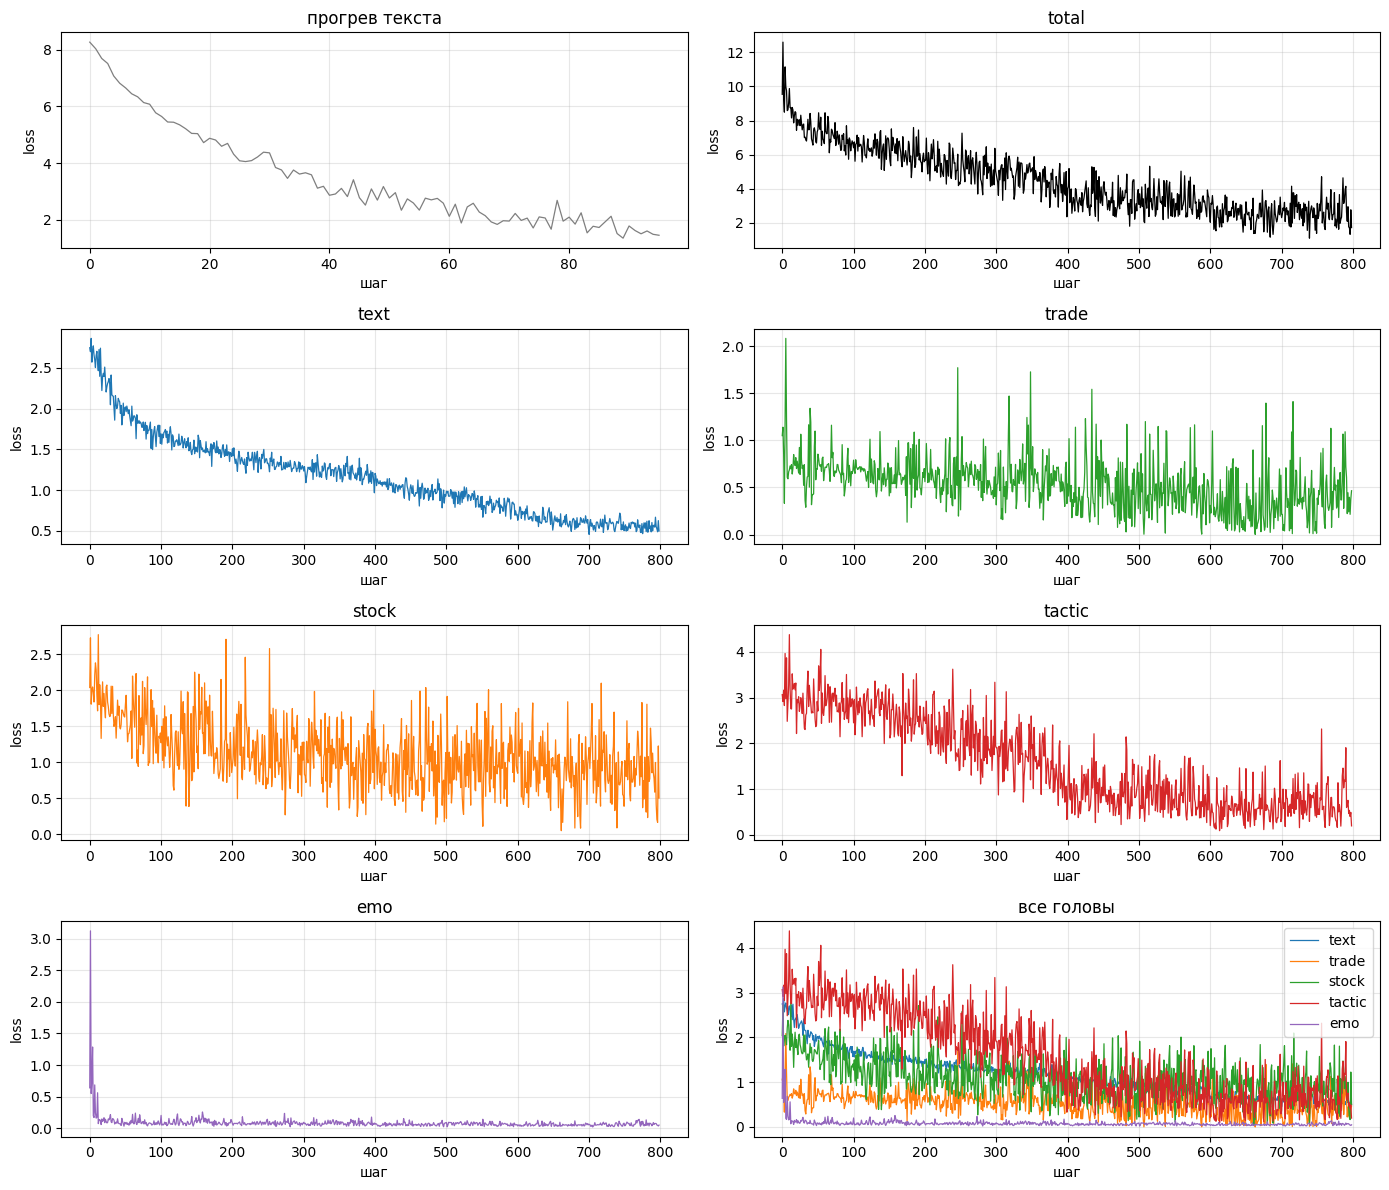

In [ ]:
import matplotlib.pyplot as plt

plots = [
    ("прогрев текста", pretrain_losses, "tab:gray"),
    ("total", history["total"], "black"),
    ("text", history["text"], "tab:blue"),
    ("trade", history["trade"], "tab:green"),
    ("stock", history["stock"], "tab:orange"),
    ("tactic", history["tactic"], "tab:red"),
    ("emo", history["emo"], "tab:purple"),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()
for ax, (title, data, color) in zip(axes, plots):
    ax.plot(data, color=color, linewidth=0.9)
    ax.set_title(title)
    ax.set_xlabel("шаг")
    ax.set_ylabel("loss")
    ax.grid(True, alpha=0.3)

# все лоссы основного обучения вместе
ax = axes[7]
for name in ["text", "trade", "stock", "tactic", "emo"]:
    ax.plot(history[name], linewidth=0.9, label=name)
ax.set_title("все головы")
ax.set_xlabel("шаг")
ax.set_ylabel("loss")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# torch.save(model.state_dict(),'mrplip_17M_3.pth')

In [29]:
_ckpt = torch.load("mrplip_17M_3.pth", map_location="cpu", weights_only=True)
tactics_count = _ckpt["tactic_choicer.weight"].shape[0]
model = MipleModel(
    vocab_size, embed_size, block_size, heads,
    decisions_count, emotions_count, market_features,
    sentiments_count, tactics_count, n_layers,
)
model.load_state_dict(_ckpt)
print("загружено, тактик:", tactics_count)

загружено, тактик: 19


In [33]:
pad_id = tokenizer.token_to_id("[PAD]")
idx2tactic = {i: t for t, i in dataset.tactic2idx.items()}


def strip_pad(ids):
    return [i for i in ids if i != pad_id]


@torch.no_grad()
def predict(model, stocks_states, events, messages, persona, max_new=40, temperature=0.9, greedy_text=False):
    model.eval()

    names = list(stocks_states.keys())
    market, _ = dataset.encode_market(stocks_states)
    market = market.unsqueeze(0)

    news_ids = strip_pad(tokenizer.encode(" ".join(events)).ids) or [sos_token_id]
    news_seq = torch.tensor([news_ids], dtype=torch.long)

    emotions = torch.zeros(1, 3)
    sentiments = persona

    context = " ".join(messages).strip()
    prompt_text = f"{context} [SOS]".strip()
    prompt = torch.tensor([strip_pad(tokenizer.encode(prompt_text).ids)], dtype=torch.long)


    trade_logits, new_emotions, tactic_logits, stock_logits, _ = model(market, prompt, news_seq, emotions, sentiments)
    decision = ["buy", "sell", "hold"][trade_logits.argmax(-1).item()]
    tactic = idx2tactic[tactic_logits.argmax(-1).item()]
    chosen_stock = names[stock_logits[0, :len(names)].argmax().item()]
    emo = new_emotions.squeeze(0).tolist()


    generated = []
    for _ in range(max_new):
        if prompt.shape[1] >= model.block_size:
            break
        _, _, _, _, text_logits = model(market, prompt, news_seq, emotions, sentiments)
        logits = text_logits[0, -1]
        if greedy_text:
            nxt = logits.argmax().item()
        else:
            probs = torch.softmax(logits / temperature, dim=-1)
            nxt = torch.multinomial(probs, 1).item()
        if nxt == eos_token_id:
            break
        generated.append(nxt)
        prompt = torch.cat([prompt, torch.tensor([[nxt]])], dim=1)

    return {
        "answer": tokenizer.decode(generated),
        "target_stock": chosen_stock,
        "decision": decision,
        "tactic": tactic,
        "emotions": {"angry": round(emo[0], 2), "sadness": round(emo[1], 2), "joy": round(emo[2], 2)},
    }

s = samples[0]
me = make_persona(["систематичный"])
result = predict(model, s["stocks_states"], s["events"], s["messages"], me)

print("новости:", s["events"])
print("персона:", [n for n, v in zip(SENTIMENTS, me.squeeze().tolist()) if v > 0.5])
print("акция:", result["target_stock"])
print("решение:", result["decision"])
print("тактика:", result["tactic"])
print("эмоции:", result["emotions"])
print("реплика:", result["answer"])

новости: ['Кризис на рынке', 'Провальный квартал', 'Негативные отзывы о продукте']
персона: ['систематичный']
акция: лиловый94
решение: hold
тактика: ожидание сигнала по индикаторам
эмоции: {'angry': 0.07, 'sadness': 0.1, 'joy': -0.13}
реплика:  Не нравится мне через мне встать4, прям свербит. связь гнидка подтверждает — закрываю, нижу его.
